## Section 1.3: Elements of Linear Algebra
**Topics:** QR Decomposition, Least-Squares Problems, and Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1FVg0KHfdEmqNZoQeusqqY40sr8Hcvg7h?usp=sharing)

In [66]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 1.3.1 QR Decomposition
QR Decomposition is a useful solution for linear least-square problems, writing the Gram-Schmidt algorithm's output in a compact vector form. In equation form, A = QR, where Q is an orthogonal matrix and R is an upper triangular matrix.

Q's orthogonality means its columns form the identity matrix I from dot product. R's upper triangular form has zeros on its bottom-left and non-zero values on its top-right.

In our example, we demonstrate this example using a 3x3 randomized A matrix, and we use this to deduce the matrices Q and R.

In [71]:
# Print out Matrix A. A is a randomized 3x3 matrix with element integer values between 1 and 20.
A = np.random.randint(1, 20, size=(3, 3)); print("Matrix A = \n", A)

# Calculate the Q and R matrices.
Q, R = np.linalg.qr(A)

# Print out Matrices Q and R, transpose matrix Q, check for orthonormal qualities and check if Q @ R can be reconstructed.
print("\nMatrix Q =\n", Q)
print("\nMatrix R =\n", R)
print("\nTranspose Vector of Q: Q.T @ Q =\n", Q.T @ Q, "\n")
print("Q @ R calculates the product of Q and R to verify the product matrix A. \nQ @ R =\n", Q @ R )
print("\nNow, let's check if Q has orthonormal columns, and whether or not matrices Q and R can recreate the product matrix A.\n")
print("1) Does Q have orthonormal columns?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("2) Can Q @ R reconstruct the matrix A?", np.allclose(Q @ R, A))

Matrix A = 
 [[19 3 11]
 [10 16 13]
 [3 4 12]]

Matrix Q =
 [[-0.87640465  0.48074023 -0.02835008]
 [-0.4612656  -0.85490357 -0.23743196]
 [-0.13837968 -0.19500955  0.97099039]]

Matrix R =
 [[-21.67948339 -10.56298233 -17.29746015]
 [  0.         -13.01627459  -8.16571849]
 [  0.           0.           8.25341832]]

Transpose Vector of Q: Q.T @ Q =
 [[ 1.00000000e+00 -2.44479281e-17  1.46848927e-17]
 [-2.44479281e-17  1.00000000e+00  2.15606549e-17]
 [ 1.46848927e-17  2.15606549e-17  1.00000000e+00]] 

Q @ R calculates the product of Q and R to verify the product matrix A. 
Q @ R =
 [[19.  3. 11.]
 [10. 16. 13.]
 [ 3.  4. 12.]]

Now, let's check if Q has orthonormal columns, and whether or not matrices Q and R can recreate the product matrix A.

1) Does Q have orthonormal columns? True
2) Can Q @ R reconstruct the matrix A? True


## Section 1.3.2. Least-Squares Problems


For the product system Ax = b, the least-square problem estimates the matrix A and b by choosing a vector x and using it to minimize residual norm of ||b - Ax||. QR Decomposition can be used to estimate the system solution, like this example below.

In [75]:
# b is a randomized 3 x 1 matrix that is between 0 and 20.
# Then, calculate least square value, residual sum, rank, and singular value of x.
# FInally, calculate residual value.
b = np.random.random(size=(3,1)) * 20; print("Matrix B =\n", b)
leastsquare_x, res_sum, rank, sing_value = np.linalg.lstsq(A, b, rcond=None)
residual_value = b - A @ leastsquare_x

# Print out the current parameters.
print("What is the least square value of x?\n", leastsquare_x)
print("What is the residual sum?", res_sum)
print("What is the rank?", rank)
print("Find the linear norms:", np.linalg.norm(res_sum))
print("What is the singular value decomposition (SVD)? ", sing_value)
print("What is the residual value?", residual_value)

# Now, use least-squares regression method with QR:
y = Q.T @ b
print("What is the value of y?\n", y)
x_qr = np.linalg.solve(R, y)
qr_residual_value = b - A @ x_qr
print("What is x using QR Decomposition?\n", x_qr)
print("What is the QR Residual Normal?", np.linalg.norm(qr_residual_value))

Matrix B =
 [[9.78881716]
 [4.52926029]
 [0.99072344]]
What is the least square value of x?
 [[ 0.54570175]
 [-0.01950088]
 [-0.04736486]]
What is the residual sum? []
What is the rank? 3
Find the linear norms: 0.0
What is the singular value decomposition (SVD)?  [31.79365342 11.58310856  6.32417569]
What is the residual value? [[-7.10542736e-15]
 [-4.44089210e-15]
 [-3.77475828e-15]]
What is the value of y?
 [[-10.80525284]
 [  0.64059688]
 [ -0.39092198]]
What is x using QR Decomposition?
 [[ 0.54570175]
 [-0.01950088]
 [-0.04736486]]
What is the QR Residual Normal? 9.155133597044475e-16


## Section 1.3.3: Linear Regression


One example of a least-squares problem is linear regression, which measures the correlation between the input matrix X and the predicted matrix Y. In equation form, y = b0 + b1*x, where b0 is the fitting y-intercept, x is the input matrix, and b1 is the slope.

In this example, we calculate the necessary parameters and provide a graphical representation of what our regression line looks like, using 7 different x and observed_y values.

Our design Matrix is =
 [[   1.    0.]
 [   1.  200.]
 [   1.  400.]
 [   1.  600.]
 [   1.  800.]
 [   1. 1000.]]
The intercept (b0) of y = b0 + b1 * x is 104.66666666666681
Slope (b1) of y = b0 + b1 * x is 0.8509999999999998
Regression residuals are
 [ 93.33333333 -73.86666667 -49.06666667 -17.26666667  10.53333333
  36.33333333]
The root mean squared error is 55.233041640750585
This is a visual representation of how the y = mx + b regression line would look like.


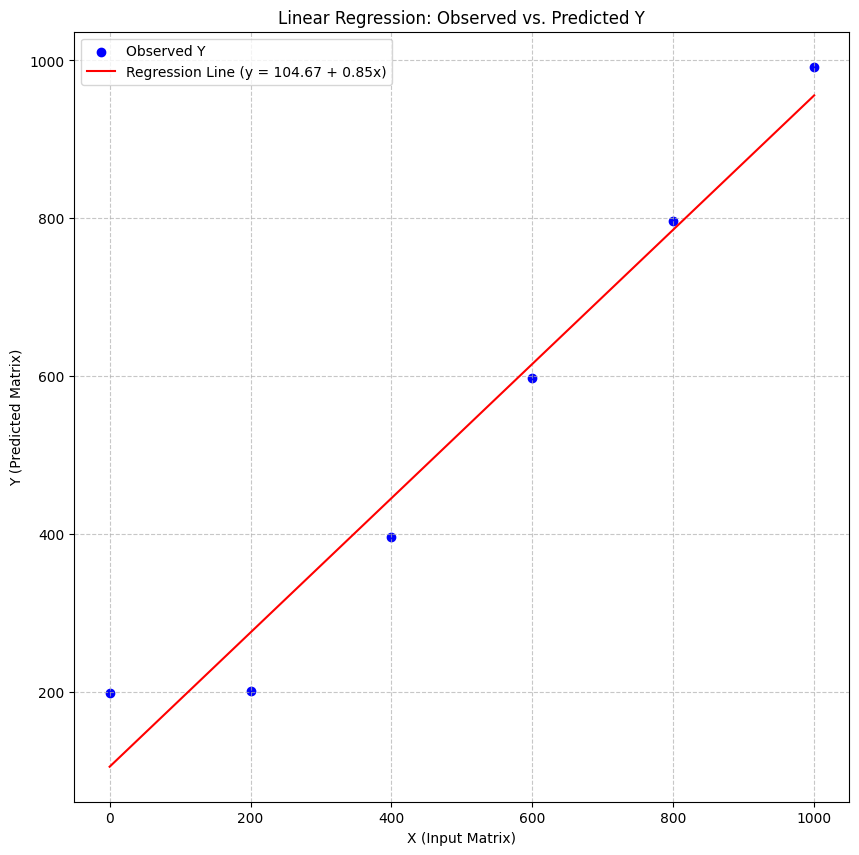

In [72]:
# Define Matrices x and observed y:
x = np.array([0, 200, 400, 600, 800, 1000], dtype=float)
observed_y = np.array([198, 201, 396, 598, 796, 992], dtype=float)

# Use np commands to find the following:
# 1) design matrix Z
# 2) y-intercept,
# 3) slope,
# 4) regression residuals
# 5) Root Mean Squared Values:

Z = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(Z, observed_y, rcond=None)
y_pred = Z @ beta
regression_residuals = observed_y - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

# Print out #1 - #6.
print("Our design Matrix is =\n", Z)
print("The intercept (b0) of y = b0 + b1 * x is", beta[0])
print("Slope (b1) of y = b0 + b1 * x is", beta[1])
print("Regression residuals are\n", regression_residuals)
print("The root mean squared error is", rmse)

# Plot the Points and the line:
print("This is a visual representation of how the y = mx + b regression line would look like.")
plt.figure(figsize=(10, 10))
plt.scatter(x, observed_y, label='Observed Y', color='blue')
plt.plot(x, y_pred, label=f'Regression Line (y = {beta[0]:.2f} + {beta[1]:.2f}x)', color='red')
plt.title('Linear Regression: Observed vs. Predicted Y')
plt.xlabel('X (Input Matrix)')
plt.ylabel('Y (Predicted Matrix)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()